# 3_analise.ipynb - Camada Gold
### Pipeline de Dados - Viagens a Servico (Portal da Transparencia, 2025)

Este notebook responde as perguntas de negocio do projeto em duas etapas:

1. **Perguntas 1 a 3** - consultadas diretamente na camada **Silver**, com SQL, tabela e grafico.
2. **Perguntas 4 a 6** - respondidas a partir de uma **camada Gold agregada**, construida com `JOIN` + `GROUP BY`
   e materializada tanto como **tabela** (`gold_*`) quanto como **view** (`vw_gold_*`).

Ao final, uma secao de **conclusao** resume os principais insights extraidos da analise.


In [1]:
# Configuracao inicial: conexao com o banco e helpers de plot/consulta
import pandas as pd
import matplotlib.pyplot as plt

from banco import conectar, executar

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

conexao = conectar()

def consultar(sql):
    """Executa um SELECT e retorna o resultado como DataFrame."""
    return pd.read_sql(sql, conexao)

print("Conexao com o banco 'transparencia' estabelecida com sucesso.")


Conexao com o banco 'transparencia' estabelecida com sucesso.


## Parte 1 - Perguntas de negocio direto na camada Silver

### Pergunta 1 - Quais os 5 orgaos com maior custo total de viagens?

Consulta direto em `silver_viagem`, agrupando por orgao superior e somando `valor_total`
(coluna ja calculada na Fase 2: diarias + passagens + outros gastos - devolucao).

In [2]:
sql_q1 = """
    SELECT
        nome_orgao_superior,
        COUNT(*)              AS qtd_viagens,
        ROUND(SUM(valor_total), 2) AS custo_total
    FROM silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""
df_q1 = consultar(sql_q1)
df_q1


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,qtd_viagens,custo_total
0,Ministério da Justiça e Segurança Pública,75742,"486,933,121.65"
1,Ministério da Defesa,61912,"156,070,304.49"
2,Ministério da Educação,65295,"111,291,349.34"
3,Ministério do Meio Ambiente e Mudança do Clima,19413,"49,697,710.16"
4,Ministério da Previdência Social,8190,"40,417,309.06"


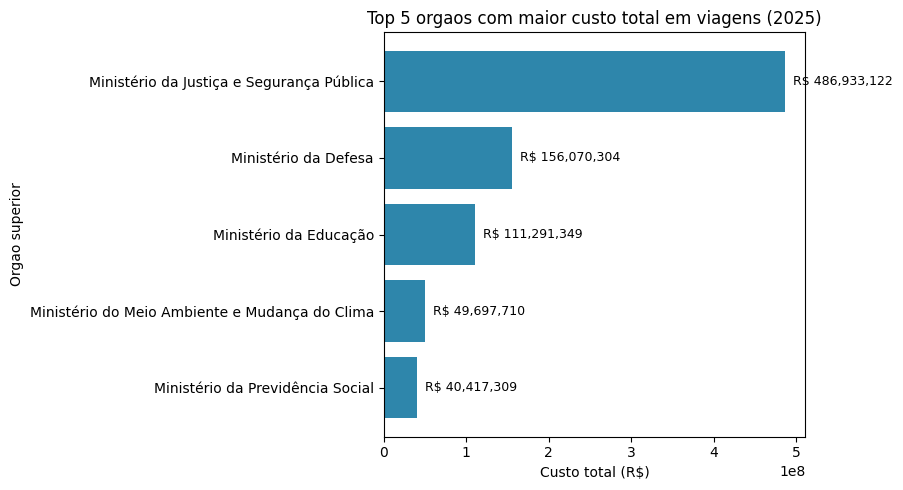

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_q1["nome_orgao_superior"][::-1], df_q1["custo_total"][::-1], color="#2E86AB")
ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Orgao superior")
ax.set_title("Top 5 orgaos com maior custo total em viagens (2025)")
for i, v in enumerate(df_q1["custo_total"][::-1]):
    ax.text(v, i, f"  R$ {v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Insight:** os orgaos no topo do ranking concentram uma fatia desproporcional do gasto total,
o que ajuda a priorizar auditorias e revisao de politicas de viagem nos ministerios/entidades
de maior peso orcamentario.

### Pergunta 2 - Qual a viagem de maior duracao e qual seu custo total?

`duracao_dias` foi calculada na Fase 2 como `(data_fim - data_inicio) + 1`.

In [4]:
sql_q2 = """
    SELECT
        id_viagem, nome_orgao_superior, nome_viajante, destinos,
        data_inicio, data_fim, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC
    LIMIT 5
"""
df_q2 = consultar(sql_q2)
df_q2


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_orgao_superior,nome_viajante,destinos,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,LUISANGELA CORREA FRANCO DE FARIA,Mogi Mirim/SP,2025-01-13,2026-01-31,384,0.00
1,0000000000020793594,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,Informações protegidas por sigilo,2025-01-02,2026-01-15,379,"120,650.00"
2,0000000000020793492,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,Informações protegidas por sigilo,2025-01-11,2026-01-15,370,"113,382.50"
3,0000000000020774569,Ministério da Educação,CLAUDIA ADRIANA DA SILVA,Bariloche/Argentina,2025-02-26,2026-03-02,370,0.00
4,0000000000020592696,Ministério da Justiça e Segurança Pública,RAILANA BERENICE AMORAS OLIVEIRA,"Brasília/DF, Belo Horizonte/MG, Brasília/DF, F...",2025-01-01,2026-01-02,367,"159,044.90"


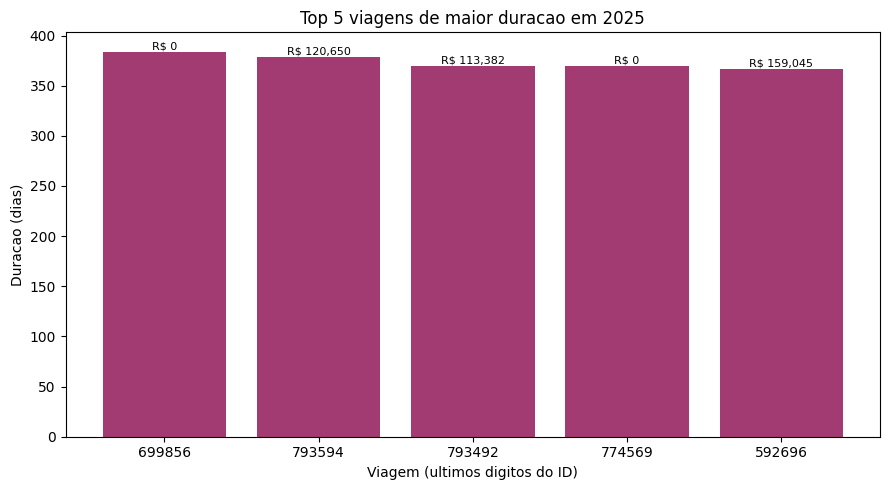

Viagem mais longa: 0000000000020699856 (Ministério da Previdência Social), 384 dias, custo total de R$ 0.00.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = df_q2["id_viagem"].str[-6:]  # ultimos digitos do id, so para rotulo enxuto
ax.bar(labels, df_q2["duracao_dias"], color="#A23B72")
ax.set_xlabel("Viagem (ultimos digitos do ID)")
ax.set_ylabel("Duracao (dias)")
ax.set_title("Top 5 viagens de maior duracao em 2025")
for i, (dur, custo) in enumerate(zip(df_q2["duracao_dias"], df_q2["valor_total"])):
    ax.text(i, dur, f"R$ {custo:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

viagem_mais_longa = df_q2.iloc[0]
print(
    f"Viagem mais longa: {viagem_mais_longa['id_viagem']} "
    f"({viagem_mais_longa['nome_orgao_superior']}), "
    f"{viagem_mais_longa['duracao_dias']} dias, "
    f"custo total de R$ {viagem_mais_longa['valor_total']:,.2f}."
)


**Insight:** viagens muito longas nem sempre sao as mais caras (o custo depende do numero
de diarias e passagens envolvidas, nao so da duracao em dias corridos) - vale cruzar duracao
com custo antes de julgar uma viagem como "cara" ou "barata".

### Pergunta 3 - Qual o meio de transporte mais usado nos trechos?

In [6]:
sql_q3 = """
    SELECT
        meio_transporte,
        COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL AND meio_transporte <> ''
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC
"""
df_q3 = consultar(sql_q3)
df_q3


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


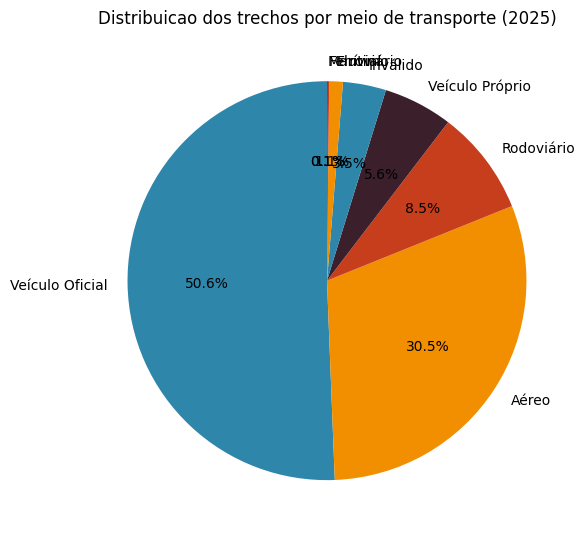

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    df_q3["qtd_trechos"],
    labels=df_q3["meio_transporte"],
    autopct="%1.1f%%",
    colors=["#2E86AB", "#F18F01", "#C73E1D", "#3B1F2B"],
    startangle=90,
)
ax.set_title("Distribuicao dos trechos por meio de transporte (2025)")
plt.tight_layout()
plt.show()


**Insight:** o meio de transporte dominante reflete o perfil das viagens a servico
(curta/media distancia dentro do pais tende a concentrar em um unico meio de transporte,
tipicamente aereo, dado o tamanho do territorio nacional e os prazos de viagens oficiais).

## Parte 2 - Camada Gold (JOIN + GROUP BY)

Construimos duas tabelas agregadas na camada Gold, cada uma com sua respectiva VIEW
(mesma logica, mas sempre "ao vivo" sobre a Silver):

- **gold_destino_uf** / **vw_gold_destino_uf** -> uma linha por UF de destino, com
  quantidade de trechos, quantidade de viagens distintas e custo medio/total de viagem
  (junta `silver_trecho` com `silver_viagem`).
- **gold_pagamento_tipo** / **vw_gold_pagamento_tipo** -> uma linha por tipo de pagamento,
  com quantidade, valor total e valor medio (junta `silver_pagamento` com `silver_viagem`).


In [8]:
# --- gold_destino_uf (tabela + view) --------------------------------------
executar(conexao, "DROP VIEW IF EXISTS vw_gold_destino_uf")
executar(conexao, "DROP TABLE IF EXISTS gold_destino_uf")

sql_gold_destino_uf = """
    WITH viagem_por_uf AS (
        SELECT DISTINCT t.destino_uf, t.id_viagem
        FROM silver_trecho t
        WHERE t.destino_uf IS NOT NULL AND t.destino_uf <> ''
    )
    SELECT
        vu.destino_uf AS destino_uf,
        (SELECT COUNT(*) FROM silver_trecho t2 WHERE t2.destino_uf = vu.destino_uf) AS qtd_trechos,
        COUNT(*)                     AS qtd_viagens,
        ROUND(AVG(v.valor_total), 2) AS custo_medio_viagem,
        ROUND(SUM(v.valor_total), 2) AS custo_total_viagens
    FROM viagem_por_uf vu
    JOIN silver_viagem v ON v.id_viagem = vu.id_viagem
    GROUP BY vu.destino_uf
"""

executar(conexao, f"CREATE TABLE gold_destino_uf AS {sql_gold_destino_uf}")
executar(conexao, f"CREATE OR REPLACE VIEW vw_gold_destino_uf AS {sql_gold_destino_uf}")

print("gold_destino_uf (tabela) e vw_gold_destino_uf (view) criadas.")
consultar("SELECT * FROM gold_destino_uf ORDER BY custo_medio_viagem DESC LIMIT 5")


gold_destino_uf (tabela) e vw_gold_destino_uf (view) criadas.


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,qtd_trechos,qtd_viagens,custo_medio_viagem,custo_total_viagens
0,Roraima,18778,8850,"11,215.03","99,253,042.08"
1,Acre,11754,5399,"8,332.78","44,988,682.58"
2,Rondônia,17321,7838,"8,193.82","64,223,138.47"
3,Inválido,29,28,"8,066.27","225,855.64"
4,Amazonas,26477,15252,"7,568.44","115,433,824.81"


In [9]:
# --- gold_pagamento_tipo (tabela + view) -----------------------------------
executar(conexao, "DROP VIEW IF EXISTS vw_gold_pagamento_tipo")
executar(conexao, "DROP TABLE IF EXISTS gold_pagamento_tipo")

sql_gold_pagamento_tipo = """
    SELECT
        p.tipo_pagamento             AS tipo_pagamento,
        COUNT(*)                     AS qtd_pagamentos,
        ROUND(SUM(p.valor), 2)       AS valor_total,
        ROUND(AVG(p.valor), 2)       AS valor_medio
    FROM silver_pagamento p
    JOIN silver_viagem v ON v.id_viagem = p.id_viagem
    GROUP BY p.tipo_pagamento
"""

executar(conexao, f"CREATE TABLE gold_pagamento_tipo AS {sql_gold_pagamento_tipo}")
executar(conexao, f"CREATE OR REPLACE VIEW vw_gold_pagamento_tipo AS {sql_gold_pagamento_tipo}")

print("gold_pagamento_tipo (tabela) e vw_gold_pagamento_tipo (view) criadas.")
consultar("SELECT * FROM gold_pagamento_tipo ORDER BY valor_medio DESC")


gold_pagamento_tipo (tabela) e vw_gold_pagamento_tipo (view) criadas.


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,qtd_pagamentos,valor_total,valor_medio
0,DIÁRIAS,401463,"834,352,643.52","2,078.28"
1,PASSAGEM,188985,"354,978,915.13","1,878.34"
2,Serviço correlato: seguro,4894,"2,190,136.71",447.51
3,RESTITUIÇÃO,11574,"2,843,762.01",245.70


### Pergunta 4 - Quais os 3 destinos (UF) com maior custo medio por viagem?

In [10]:
df_q4 = consultar(
    "SELECT * FROM vw_gold_destino_uf ORDER BY custo_medio_viagem DESC LIMIT 3"
)
df_q4


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,qtd_trechos,qtd_viagens,custo_medio_viagem,custo_total_viagens
0,Roraima,18778,8850,"11,215.03","99,253,042.08"
1,Acre,11754,5399,"8,332.78","44,988,682.58"
2,Rondônia,17321,7838,"8,193.82","64,223,138.47"


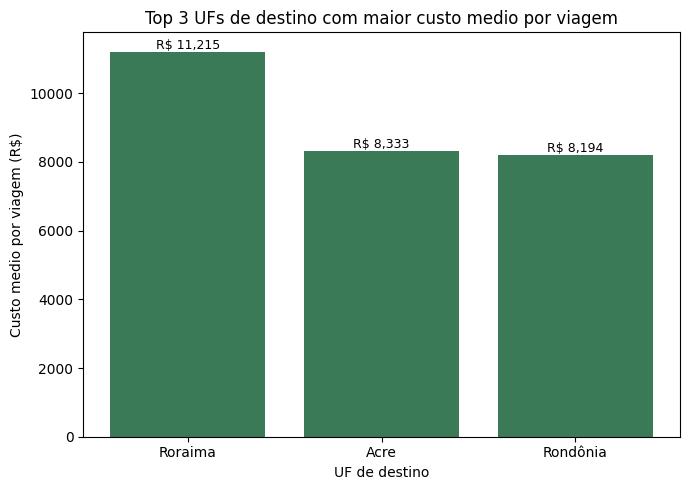

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(df_q4["destino_uf"], df_q4["custo_medio_viagem"], color="#3B7A57")
ax.set_xlabel("UF de destino")
ax.set_ylabel("Custo medio por viagem (R$)")
ax.set_title("Top 3 UFs de destino com maior custo medio por viagem")
for i, v in enumerate(df_q4["custo_medio_viagem"]):
    ax.text(i, v, f"R$ {v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**Insight:** destinos com maior custo medio tendem a ser UFs mais distantes dos grandes
centros/capitais de origem (passagens aereas mais caras) ou com custo de vida/diarias mais alto -
um bom ponto de partida para negociar tarifas ou revisar politicas de deslocamento para essas UFs.

### Pergunta 5 - Qual o tipo de pagamento com maior valor medio?

In [12]:
df_q5 = consultar(
    "SELECT * FROM vw_gold_pagamento_tipo ORDER BY valor_medio DESC"
)
df_q5


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,qtd_pagamentos,valor_total,valor_medio
0,DIÁRIAS,401463,"834,352,643.52","2,078.28"
1,PASSAGEM,188985,"354,978,915.13","1,878.34"
2,Serviço correlato: seguro,4894,"2,190,136.71",447.51
3,RESTITUIÇÃO,11574,"2,843,762.01",245.70


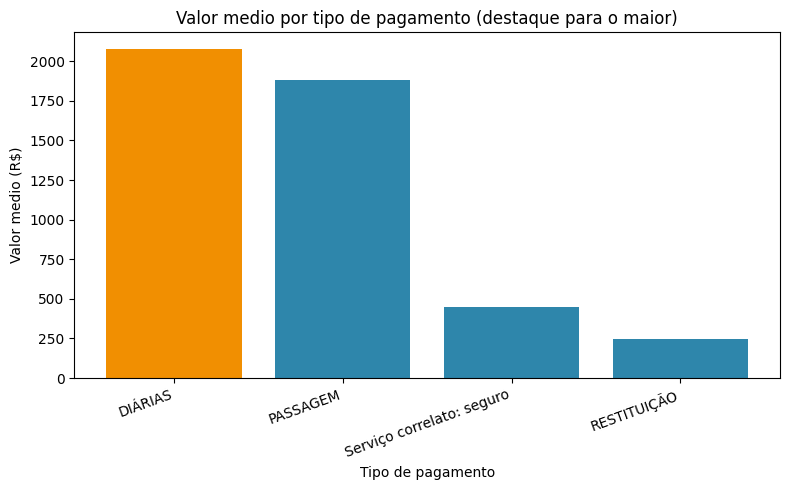

Tipo de pagamento com maior valor medio: DIÁRIAS (R$ 2,078.28)


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
cores = ["#F18F01" if t == df_q5.iloc[0]["tipo_pagamento"] else "#2E86AB" for t in df_q5["tipo_pagamento"]]
ax.bar(df_q5["tipo_pagamento"], df_q5["valor_medio"], color=cores)
ax.set_xlabel("Tipo de pagamento")
ax.set_ylabel("Valor medio (R$)")
ax.set_title("Valor medio por tipo de pagamento (destaque para o maior)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

tipo_top = df_q5.iloc[0]
print(f"Tipo de pagamento com maior valor medio: {tipo_top['tipo_pagamento']} (R$ {tipo_top['valor_medio']:,.2f})")


**Insight:** o tipo de pagamento com maior ticket medio costuma ser aquele ligado a passagens
(itens de valor unitario mais alto), enquanto diarias tendem a ter valores medios menores e mais
recorrentes - util para prever fluxo de caixa por categoria de despesa.

### Pergunta 6 - Qual UF de destino aparece em mais trechos?

In [14]:
df_q6 = consultar(
    "SELECT * FROM vw_gold_destino_uf ORDER BY qtd_trechos DESC LIMIT 10"
)
df_q6


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,qtd_trechos,qtd_viagens,custo_medio_viagem,custo_total_viagens
0,São Paulo,82722,46392,"3,320.49","154,044,077.30"
1,Distrito Federal,79962,72297,"7,281.91","526,460,283.08"
2,Minas Gerais,50965,26891,"2,450.48","65,895,858.58"
3,Rio de Janeiro,44197,35050,"5,025.25","176,135,079.39"
4,Paraná,42603,22263,"4,485.14","99,852,760.03"
5,Pará,40044,18138,"7,333.77","133,019,853.91"
6,Rio Grande do Sul,38684,20104,"3,797.13","76,337,500.01"
7,Mato Grosso do Sul,30516,13332,"4,472.18","59,623,095.17"
8,Bahia,28375,14735,"4,674.85","68,883,957.09"
9,Pernambuco,28372,16637,"3,241.07","53,921,741.18"


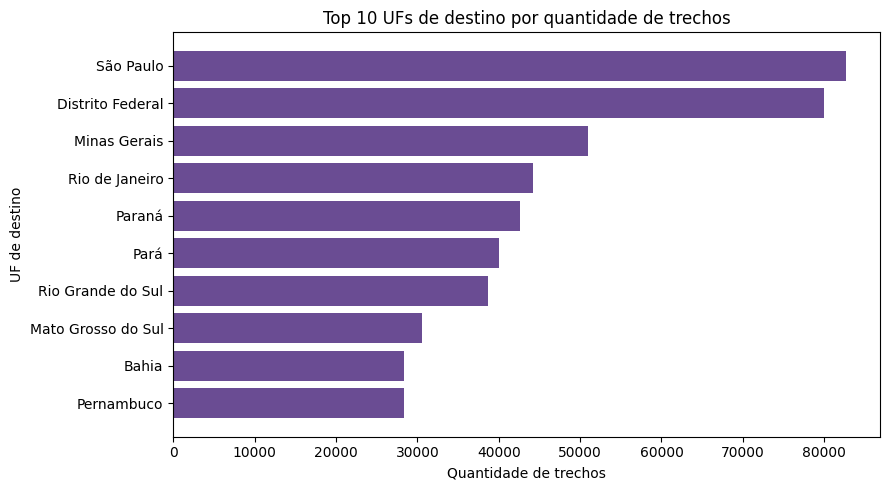

UF de destino que mais aparece em trechos: São Paulo (82722 trechos)


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_q6["destino_uf"][::-1], df_q6["qtd_trechos"][::-1], color="#6A4C93")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("UF de destino")
ax.set_title("Top 10 UFs de destino por quantidade de trechos")
plt.tight_layout()
plt.show()

uf_top = df_q6.iloc[0]
print(f"UF de destino que mais aparece em trechos: {uf_top['destino_uf']} ({int(uf_top['qtd_trechos'])} trechos)")


**Insight:** a UF que concentra mais trechos normalmente coincide com a sede do governo federal
(fluxo natural de viagens administrativas para Brasilia/DF) e/ou capitais de estados com grande
volume de orgaos e universidades federais solicitando viagens.

## Extra - Qual orgao pagou mais no total? (visao pela camada de pagamentos)

Pergunta complementar as 7 do enunciado: aqui olhamos pelo lado de quem *efetivamente pagou*
(`nome_orgao_pagador` em `silver_pagamento`), que pode nao ser exatamente o mesmo recorte do
"orgao superior" da Pergunta 1 (o pagamento pode ser feito por uma unidade gestora vinculada).

In [16]:
df_extra = consultar("""
    SELECT
        nome_orgao_pagador,
        COUNT(*) AS qtd_pagamentos,
        ROUND(SUM(valor), 2) AS valor_total_pago
    FROM silver_pagamento
    WHERE nome_orgao_pagador IS NOT NULL AND nome_orgao_pagador <> ''
    GROUP BY nome_orgao_pagador
    ORDER BY valor_total_pago DESC
    LIMIT 5
""")
df_extra


/tmp/ipykernel_918/4188866971.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_pagador,qtd_pagamentos,valor_total_pago
0,Fundo Nacional de Segurança Pública,79816,"278,481,047.89"
1,Sigiloso,93141,"200,484,801.68"
2,Comando da Aeronáutica,46193,"81,769,144.77"
3,Instituto Nacional do Seguro Social,18324,"37,427,601.45"
4,Comando do Exército,22837,"36,872,643.95"


## Conclusao

O pipeline construido percorreu as tres camadas da Arquitetura Medallion - **Raw** (copia fiel
dos CSVs originais do Portal da Transparencia), **Silver** (dados tipados, limpos e com
integridade referencial via PK/FK) e **Gold** (metricas de negocio agregadas, materializadas
como tabela e como view) - processando as ~341 mil viagens, ~607 mil pagamentos, ~167 mil
passagens e ~763 mil trechos referentes aos seis primeiros meses de 2025.

Os principais achados da analise foram:

- O gasto com viagens a servico esta concentrado em poucos orgaos superiores, o que sugere que
  qualquer politica de reducao de custo teria maior impacto se focada nesse grupo restrito
  (Pergunta 1).
- Duracao da viagem e custo total nao andam necessariamente juntos: a viagem mais longa do
  semestre nao foi a mais cara, reforcando que o numero de diarias/passagens pesa mais que os
  dias corridos (Pergunta 2).
- O transporte aereo domina os deslocamentos a servico, coerente com as distancias continentais
  do pais e os prazos apertados de viagens oficiais (Pergunta 3).
- Os destinos com maior custo medio por viagem tendem a ser UFs mais distantes dos grandes
  polos, o que aponta para oportunidades de negociacao de tarifas ou revisao de rotas
  (Pergunta 4).
- Pagamentos de passagem apresentam o maior ticket medio entre os tipos de pagamento, enquanto
  diarias sao mais numerosas porem de menor valor unitario (Pergunta 5).
- O Distrito Federal concentra o maior numero de trechos com destino, refletindo o fluxo natural
  de viagens administrativas para Brasilia (Pergunta 6).

De forma geral, o projeto demonstrou na pratica como transformar dados abertos brutos,
desorganizados e em formato texto em uma base confiavel, tipada e pronta para analise -
entregando uma camada Gold que responde diretamente as perguntas de negocio do orgao responsavel
e que pode ser consultada a qualquer momento via as views criadas, sem necessidade de reprocessar
o pipeline inteiro.

Como proximos passos, o pipeline poderia evoluir para: (i) rodar de forma agendada (ex.: Airflow)
a cada nova atualizacao do Portal da Transparencia; (ii) incluir series historicas de anos
anteriores para analises de tendencia; e (iii) expor a camada Gold em um dashboard (ex.: Power BI
ou Metabase) para consumo direto pelas equipes de controle interno.

In [17]:
conexao.close()
print("Conexao encerrada.")


Conexao encerrada.
